In [1]:
import torch
import numpy as np
import pandas as pd
import einops as eops
import torch.nn as nn

In [2]:
import kagglehub
import pathlib
from torch.utils.data import TensorDataset, DataLoader

D:\MiniConda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
path = kagglehub.dataset_download("emirhanakku/synthetic-medical-triage-priority-dataset")
path

'C:\\Users\\ayush\\.cache\\kagglehub\\datasets\\emirhanakku\\synthetic-medical-triage-priority-dataset\\versions\\1'

In [14]:
path = path.split('\\')[-2]

In [17]:
files = pathlib.Path("").glob("*.csv")

In [18]:
dataset = list(files)[0]
dataset

WindowsPath('synthetic_medical_triage.csv')

In [19]:
data = pd.read_csv(dataset)

In [34]:
d = data.head(2)

d.to_csv('trial.c')

In [21]:
OnehotCol = ['pain_level', 'arrival_mode', 'chronic_disease_count', 'previous_er_visits']
data = pd.get_dummies(data, columns=OnehotCol, dtype=int)

normCol = ['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation', 'body_temperature']
for col in normCol:
    data[col] = (data[col] - data[col].mean())/ data[col].std()

In [22]:
yCol = ['triage_level']
df_y = data[yCol]
df_x = data.drop(yCol, axis = 1)

df_x, df_y

(            age  heart_rate  systolic_blood_pressure  oxygen_saturation  \
 0     -1.403914    0.713711                 1.011374           0.394741   
 1      1.805332    3.808426                 1.622645          -0.025574   
 2      0.334210    0.224451                 0.006764           0.724990   
 3      0.632622    0.082978                 1.016690          -1.076363   
 4     -0.288793   -1.490905                -1.077576           0.875102   
 ...         ...         ...                      ...                ...   
 17995  0.423210    0.990761                 0.899751          -0.205709   
 17996 -0.398734    0.088873                -0.003866           0.574877   
 17997  0.758270   -1.084171                -1.327400          -0.656048   
 17998  1.344625    0.430765                 0.851912           0.004448   
 17999  1.538331    0.147820                 0.171542          -0.025574   
 
        body_temperature  pain_level_1  pain_level_2  pain_level_3  \
 0             -

In [23]:
np_x = df_x.to_numpy()
np_y = df_y.to_numpy()

In [24]:
class AmbSelModel(nn.Module):
    def __init__(self, _nf :int):
        super(AmbSelModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(_nf, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.Dropout(p=0.25),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, inp):
        return self.model(inp)

In [25]:
class Train():
    def __init__(self, _nFeature :int):
        self.model = AmbSelModel(_nFeature)
        self.loss = nn.CrossEntropyLoss()
        self.optim = torch.optim.Adam(self.model.parameters(), lr=0.01)
        self.histX = []
        self.histY = []

    def train(self, X :np.ndarray, Y :np.ndarray, epochs:int=100, _nbatch:int=32):
        print("Training starts")
        model = self.model
        optim = self.optim
        loss_fn = self.loss
        
        X = torch.from_numpy(X).float()
        Y = torch.from_numpy(Y).long().squeeze()
        print(Y)

        inp = TensorDataset(X, Y)
        data_loader = DataLoader(inp, batch_size=_nbatch, shuffle=True)
            
        for epoch in range(epochs):
            model.train()
            self.histY.append(epoch)

            avg_loss = 0

            for i, (train_X, train_Y) in enumerate(data_loader):
                optim.zero_grad()
                pred = model(train_X)
                class_loss = loss_fn(pred, train_Y)
                class_loss.backward()
                optim.step()
                avg_loss += class_loss.mean()
                
            epoch_loss = avg_loss / len(data_loader)
            self.histX.append(epoch_loss.item())
            print(f"Epoch {epoch}: Average Loss = {epoch_loss:.4f}")

#simple softmax between triage-level
    def pred(self, inp :np.ndarray, k :int=3):
        with torch.no_grad():
            inp = torch.Tensor(inp)
            pred_score = torch.softmax(self.model(inp))
            idx = []
            print(pred_score)
            for i in range(len(pred_score)):
                arg = torch.argmax(pred_score[i])
                pred_score[i] = arg+1

            return pred_score

    def save(self, name :str):
        torch.save(self.model.state_dict(), name)

In [26]:
model = Train(np_x.shape[-1])
np_x.shape

(18000, 41)

In [27]:
model.train(np_x, np_y, epochs=256, _nbatch=64)

Training starts
tensor([0, 3, 1,  ..., 1, 0, 2])


C:\Users\ayush\AppData\Local\Temp\ipykernel_20028\1188581429.py:16: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  Y = torch.from_numpy(Y).long().squeeze()


Epoch 0: Average Loss = 0.2557
Epoch 1: Average Loss = 0.2035
Epoch 2: Average Loss = 0.1965
Epoch 3: Average Loss = 0.1932
Epoch 4: Average Loss = 0.1936
Epoch 5: Average Loss = 0.1923
Epoch 6: Average Loss = 0.1872
Epoch 7: Average Loss = 0.1861
Epoch 8: Average Loss = 0.1831
Epoch 9: Average Loss = 0.1831
Epoch 10: Average Loss = 0.1819
Epoch 11: Average Loss = 0.1803
Epoch 12: Average Loss = 0.1763
Epoch 13: Average Loss = 0.1762
Epoch 14: Average Loss = 0.1812
Epoch 15: Average Loss = 0.1770
Epoch 16: Average Loss = 0.1720
Epoch 17: Average Loss = 0.1696
Epoch 18: Average Loss = 0.1662
Epoch 19: Average Loss = 0.1666
Epoch 20: Average Loss = 0.1644
Epoch 21: Average Loss = 0.1655
Epoch 22: Average Loss = 0.1645
Epoch 23: Average Loss = 0.1636
Epoch 24: Average Loss = 0.1637
Epoch 25: Average Loss = 0.1661
Epoch 26: Average Loss = 0.1598
Epoch 27: Average Loss = 0.1582
Epoch 28: Average Loss = 0.1591
Epoch 29: Average Loss = 0.1546
Epoch 30: Average Loss = 0.1552
Epoch 31: Average 

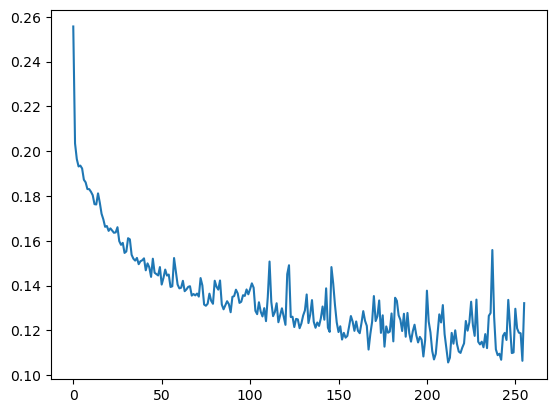

In [28]:
#Earlier Err rate saturated at 20% -> 12.5% -> (<=11%)
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  

import matplotlib.pyplot as plt

plt.plot(model.histY, model.histX)
plt.show()

In [29]:
model.save("AmbSelectorModel.pth")